In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split

In [2]:
# Set image size
SIZE = 224

# Directories for training and testing data
train_dir = "../datasets/dataset3/train"
test_dir = "../datasets/dataset3/test"

# Initialize lists for real and forged images
real_images = []
forged_images = []

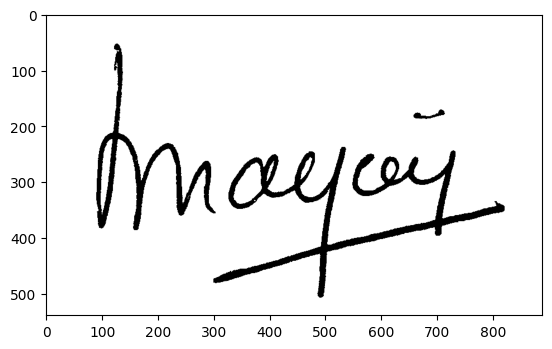

In [3]:
img = cv2.imread('../datasets/dataset4/train/008/00801008.png')
plt.imshow(img)

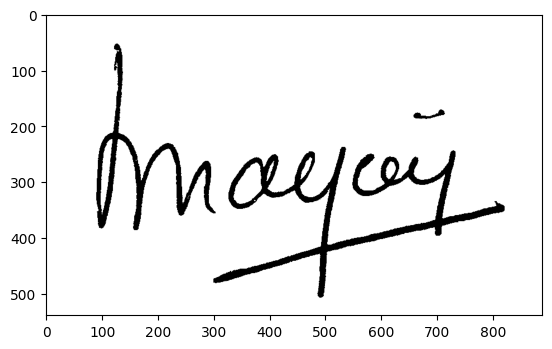

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray,cv2.COLOR_BGR2RGB))

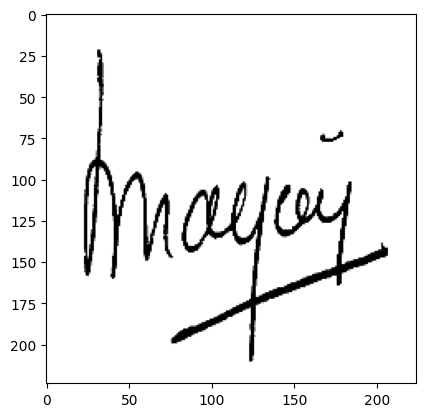

In [5]:
img = cv2.resize(gray, (SIZE, SIZE))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

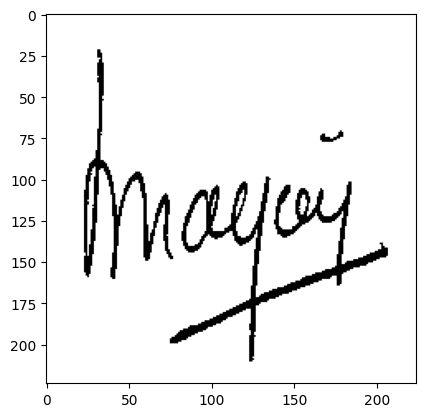

In [6]:
img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=55, C=6)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

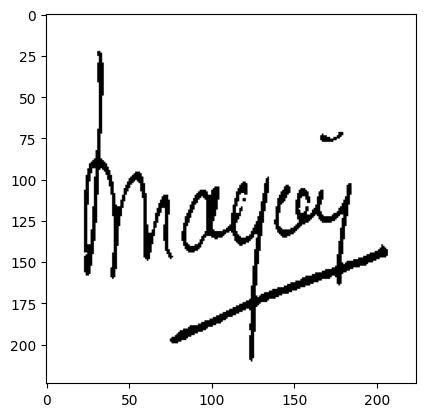

In [7]:
img = cv2.medianBlur(img,ksize=3)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

In [8]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)  
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  
    img = cv2.resize(img, (SIZE, SIZE))  
    
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=55, C=6)  
    img = cv2.medianBlur(img,ksize=3)  
    
    return img

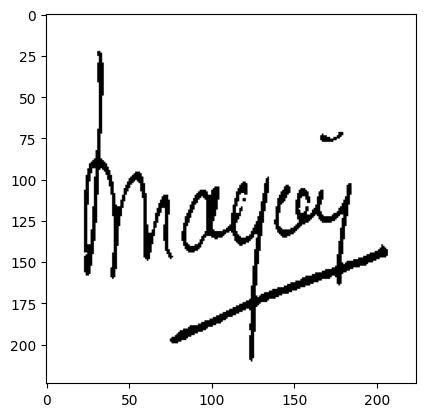

In [9]:
img = preprocess_image('../datasets/dataset4/train/008/00801008.png')
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

In [10]:
# Function to read and preprocess images from a directory
def load_images_from_directory(directory):
    real_imgs = []
    forged_imgs = []
    
    for per in os.listdir(directory):
        for data in glob.glob(os.path.join(directory, per, '*.*')):
            try:
                img = preprocess_image(data)
                if per[-1] == 'g':
                    forged_imgs.append(img)
                else:
                    real_imgs.append(img)
            except Exception as e:
                print(f"Error reading image {data}: {e}")
    
    return np.array(real_imgs), np.array(forged_imgs)

In [11]:
# Load and preprocess train images
real_images_train, forged_images_train = load_images_from_directory(train_dir)

# Create labels for real and forged images
real_labels_train = np.zeros((real_images_train.shape[0], 1))
forged_labels_train = np.ones((forged_images_train.shape[0], 1))

# Concatenate images and labels
images_train = np.concatenate((real_images_train, forged_images_train))
labels_train = np.concatenate((real_labels_train, forged_labels_train))

# Flatten images
images_train = images_train.reshape(images_train.shape[0], -1)

train_data = images_train
train_labels = labels_train

In [12]:
# Load and preprocess test images
real_images_test, forged_images_test = load_images_from_directory(test_dir)

# Create labels for real and forged images
real_labels_test = np.zeros((real_images_test.shape[0], 1))
forged_labels_test = np.ones((forged_images_test.shape[0], 1))

# Concatenate images and labels
images_test = np.concatenate((real_images_test, forged_images_test))
labels_test = np.concatenate((real_labels_test, forged_labels_test))

# Flatten images
images_test = images_test.reshape(images_test.shape[0], -1)

test_data = images_test
test_labels = labels_test

In [13]:
# Save preprocessed data
np.save('../datasets/dataset3/X_train.npy', train_data)
np.save('../datasets/dataset3/y_train.npy', train_labels)
np.save('../datasets/dataset3/X_test.npy', test_data)
np.save('../datasets/dataset3/y_test.npy', test_labels)

In [14]:
# Function to display random images
def show_random_images(images, labels, title):
    plt.figure(figsize=(10, 4))
    random_indices = random.sample(range(len(images)), min(3, len(images)))
    for i, idx in enumerate(random_indices):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[idx].reshape(SIZE, SIZE), cmap='gray')
        plt.title(f"Label: {int(labels[idx])}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

In [15]:
load_images_from_directory(train_dir)

(array([[[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]],
 
        [[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]],
 
        [[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]],
 
        ...,
 
        [[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255,

C:\Users\HP\AppData\Local\Temp\ipykernel_18952\1253021693.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[idx])}")


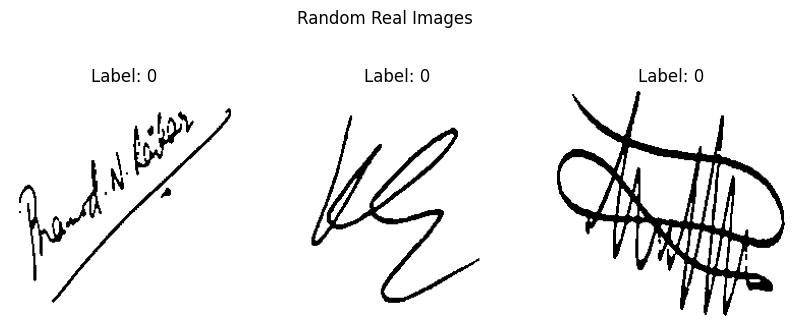

In [24]:
# Display a random set of real images
show_random_images(real_images_train, real_labels_train, "Random Real Images")

C:\Users\HP\AppData\Local\Temp\ipykernel_18952\1253021693.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[idx])}")


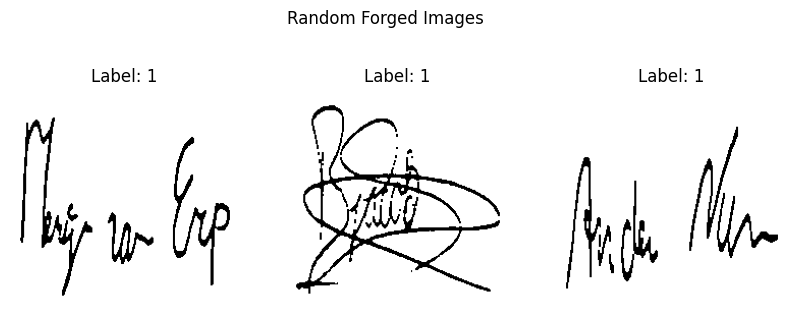

In [25]:
# Display a random set of forged images
show_random_images(forged_images_train, forged_labels_train, "Random Forged Images")

In [18]:
def process_and_show_image(img_path):
    # Lecture de l'image originale
    original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Prétraitement de l'image
    processed_img = preprocess_image(img_path)
    
    # Affichage des images avant et après prétraitement
    plt.figure(figsize=(10, 5))
    
    # Affichage de l'image originale
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # Affichage de l'image prétraitée
    plt.subplot(1, 2, 2)
    plt.imshow(processed_img, cmap='gray')
    plt.title('Processed Image')
    plt.axis('off')
    
    plt.show()


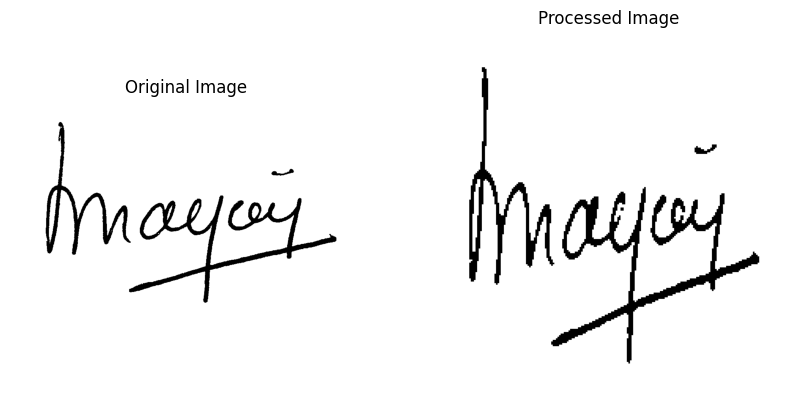

In [19]:
# Example usage of process_and_show_image function
example_img_path = "../datasets/dataset4/train/008/00801008.png"  
process_and_show_image(example_img_path)

In [20]:
# Example usage of process_and_show_image function
example_img_path = "../datasets/dataset4/train/002/00201002.png"  # Replace with a valid image path
process_and_show_image1(example_img_path)

NameError: name 'process_and_show_image1' is not defined